Using device: cuda
Fetched 1258 daily rows of data from FMP.
Saved raw data to 'aapl.csv'.
Data after computing indicators: (1239, 12)
Final X shape: (1234, 5, 9)
Final y shape: (1234,)

===== Fold 1 =====
Train range: 0 to 410, Val range: 411 to 821
Epoch [1/40], Train Loss: 0.046850, Val Loss (scaled): 0.006094
Epoch [2/40], Train Loss: 0.011611, Val Loss (scaled): 0.037904
Epoch [3/40], Train Loss: 0.008834, Val Loss (scaled): 0.009217
Epoch [4/40], Train Loss: 0.004504, Val Loss (scaled): 0.001449
Epoch [5/40], Train Loss: 0.001369, Val Loss (scaled): 0.003107
Epoch [6/40], Train Loss: 0.001123, Val Loss (scaled): 0.001805
Epoch [7/40], Train Loss: 0.000913, Val Loss (scaled): 0.001271
Epoch [8/40], Train Loss: 0.000685, Val Loss (scaled): 0.001349
Epoch [9/40], Train Loss: 0.000692, Val Loss (scaled): 0.000787
Epoch [10/40], Train Loss: 0.000719, Val Loss (scaled): 0.001033
Epoch [11/40], Train Loss: 0.000665, Val Loss (scaled): 0.000835
Epoch [12/40], Train Loss: 0.000583, Val Lo

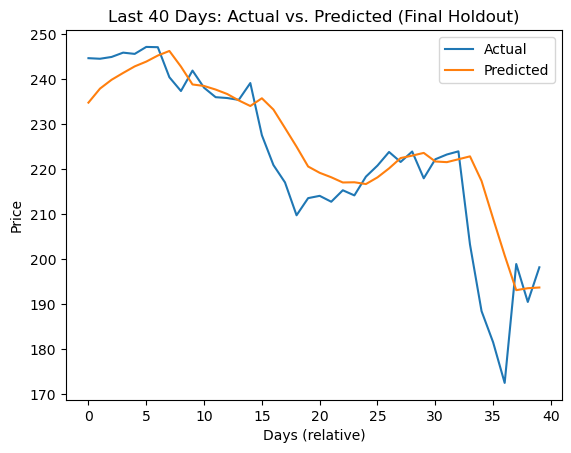

In [5]:
import requests  
import pandas as pd 
import numpy as np  
import torch  
import torch.nn as nn  
import torch.optim as optim 
from torch.utils.data import Dataset, DataLoader  
from sklearn.preprocessing import MinMaxScaler  
from sklearn.metrics import r2_score, mean_absolute_percentage_error  
import matplotlib.pyplot as plt  

# 1: Fetch Data from FMP API
def fetch_data_fmp(ticker, api_key):
    """
    Fetches daily historical stock data for the given ticker using FMP's API.
    Returns a Pandas DataFrame with the date set as the index.
    """
    url = f"https://financialmodelingprep.com/api/v3/historical-price-full/{ticker}?apikey={api_key}"  # Construct URL
    response = requests.get(url)  
    if response.status_code != 200:  
        raise ValueError(f"Request failed with status code {response.status_code}")  

    data = response.json()  

    # Validate that the expected key exists and is a list
    if "historical" not in data or not isinstance(data["historical"], list):
        raise ValueError(f"Unexpected response for {ticker}: {data}")

    records = data["historical"]  # Get historical records
    if len(records) == 0: 
        raise ValueError(f"No daily data returned for {ticker}.")

    df = pd.DataFrame(records)  # Convert list of records to DataFrame
    df = df[["date", "open", "high", "low", "close", "volume"]]  
    df["date"] = pd.to_datetime(df["date"])  # Convert 'date' column to datetime objects
    df = df.sort_values("date").reset_index(drop=True)  # Sort DataFrame by date and reset index
    df.set_index("date", inplace=True)  
    return df 

# 2: Compute Technical Indicators
def compute_indicators(df):
    """
    Computes common technical indicators (RSI, MACD, Bollinger Bands) and adds them to the DataFrame.
    Drops any rows with NaN values that result from rolling calculations.
    """
    df = df.rename(columns={ 
        'open': 'Open',
        'high': 'High',
        'low': 'Low',
        'close': 'Close',
        'volume': 'Volume'
    })

    # RSI Calculation (14-day) 
    window_rsi = 14  # RSI period
    delta = df['Close'].diff()  
    gain = delta.clip(lower=0)  # Keep positive changes only
    loss = -1 * delta.clip(upper=0)  # Convert negative changes to positive values

    roll_up = gain.ewm(span=window_rsi).mean()  # Compute exponential moving average for gains
    roll_down = loss.ewm(span=window_rsi).mean()  
    rs = roll_up / roll_down  # Calculate relative strength (RS)
    rsi = 100.0 - (100.0 / (1.0 + rs))  # Compute RSI from RS
    df['RSI'] = rsi  

    # MACD Calculation (12,26,9)
    ema12 = df['Close'].ewm(span=12, adjust=False).mean()  
    ema26 = df['Close'].ewm(span=26, adjust=False).mean()  # 26-day EMA
    macd = ema12 - ema26  # MACD line 
    signal = macd.ewm(span=9, adjust=False).mean()  # 9-day EMA of MACD 
    histogram = macd - signal  # MACD 
    df['MACD'] = macd  # Add MACD column
    df['MACD_Signal'] = signal  # Add MACD signal column
    df['MACD_Hist'] = histogram  

    # ----- Bollinger Bands Calculation (20-day SMA) -----
    window_bb = 20  # Bollinger Bands period
    sma = df['Close'].rolling(window=window_bb).mean()  # 20-day Simple Moving Average (SMA)
    std = df['Close'].rolling(window=window_bb).std()  # 20-day rolling standard deviation
    df['BB_Mid'] = sma  # Middle Bollinger Band (SMA)
    df['BB_Upper'] = sma + 2 * std  # Upper Bollinger Band 
    df['BB_Lower'] = sma - 2 * std  # Lower Bollinger Band (SMA - 2 * std)

    df.dropna(inplace=True)  
    return df  # Return the DataFrame with new indicator columns

# 3: Prepare Data (Windowed Sequences)
def prepare_data(df, feature_cols, target_col='Close', window_size=60):
    """
    Creates sliding window sequences from the DataFrame.
    Scales features and target together using MinMaxScaler.
    Returns:
        X: input sequences with shape (samples, window_size, num_features)
        y: target values with shape (samples,)
        scaler: fitted scaler object for inverse transformations
    """
    data = df[feature_cols].values  # Extract feature values as a NumPy array
    target = df[target_col].values.reshape(-1, 1)  # Extract target values and reshape to 2D

    scaler = MinMaxScaler(feature_range=(0, 1))  # Initialize scaler to scale values between 0 and 1
    data_combined = np.hstack([data, target])  # Combine features and target horizontally
    data_scaled = scaler.fit_transform(data_combined)  # Fit scaler and transform the data

    n_features = len(feature_cols)  
    features_scaled = data_scaled[:, :n_features]  
    target_scaled = data_scaled[:, n_features]  

    X, y = [], []  # Initialize lists to hold sequences and targets
    for i in range(window_size, len(df)):  
        X.append(features_scaled[i - window_size:i])  
        y.append(target_scaled[i])  

    X = np.array(X)  
    y = np.array(y)  
    return X, y, scaler

# Combined Scaling:
# We horizontally stack (concatenate) the feature array and the target column into one array.
# The MinMaxScaler is then fitted on this combined array, which calculates the minimum and maximum
# values for each column (feature and target). After scaling, the features and target are separated again.
# The features occupy the first columns of the scaled array, and the target is in the last column.  

# 4: Custom PyTorch Dataset for Stock Data
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = X  # Store input sequences
        self.y = y  # Store corresponding targets

    def __len__(self):
        return len(self.X)  # Return the number of samples

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]  # Return a specific sample and its target

# 5: LSTM Model Definition
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=50, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()  # Initialize the superclass
        self.hidden_dim = hidden_dim  # Set hidden dimension size
        self.num_layers = num_layers  # Set number of LSTM layers
        # Create LSTM layer with specified input dimension, hidden dimension, and number of layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)  # Create a fully connected output layer

    def forward(self, x):
        batch_size = x.size(0)  # Get the batch size
        # Initialize hidden state and cell state with zeros
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(x.device)
        out, (hn, cn) = self.lstm(x, (h0, c0))  # Forward pass through LSTM layers
        out = out[:, -1, :]  # Use the output from the last time step
        out = self.fc(out)  # Pass through the fully connected layer to get final output
        return out  # Return the prediction

# 6: Early Stopping Class to Monitor Validation Loss
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-5):
        self.patience = patience  # Maximum number of epochs to wait for improvement
        self.min_delta = min_delta  # Minimum change in loss to qualify as an improvement
        self.best_loss = None  # Best observed validation loss
        self.counter = 0  # Counter for epochs with no improvement
        self.should_stop = False  # Flag to indicate whether training should stop

    def __call__(self, val_loss):
        if self.best_loss is None:  # If no best loss yet, set current loss as best loss
            self.best_loss = val_loss
        elif self.best_loss - val_loss > self.min_delta:  # If loss has improved sufficiently
            self.best_loss = val_loss  # Update the best loss
            self.counter = 0  # Reset the counter
        else:
            self.counter += 1  # Increment the counter if no sufficient improvement
            if self.counter >= self.patience:  # If counter exceeds patience, trigger stopping
                self.should_stop = True

# 7: Training Loop Function
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=50, early_stopping=None):
    model.to(device)  # Move the model to the specified device (CPU/GPU)
    for epoch in range(epochs):  # Loop over epochs
        model.train()  # Set model to training mode
        train_loss = 0.0  # Initialize training loss
        for X_batch, y_batch in train_loader:  # Loop over training batches
            X_batch = X_batch.float().to(device)  # Convert inputs to float and send to device
            y_batch = y_batch.float().to(device)  # Convert targets to float and send to device

            optimizer.zero_grad()  # Clear gradients from previous iteration
            outputs = model(X_batch).squeeze()  # Forward pass
            loss = criterion(outputs, y_batch)  # Compute loss
            loss.backward()  # Backpropagate to compute gradients
            optimizer.step()  # Update model parameters

            train_loss += loss.item() * X_batch.size(0)  # Accumulate loss 
        train_loss /= len(train_loader.dataset)  # Compute average training loss

        # Evaluate on validation set
        model.eval() 
        val_loss = 0.0 
        with torch.no_grad():  # Disable gradient computation for validation
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.float().to(device)
                y_batch = y_batch.float().to(device)
                outputs = model(X_batch).squeeze()  # Forward pass
                loss = criterion(outputs, y_batch)  # Compute loss
                val_loss += loss.item() * X_batch.size(0)  # Accumulate validation loss
        val_loss /= len(val_loader.dataset)  # Average validation loss

        # Print losses for the current epoch
        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

        # Check if early stopping should be triggered
        if early_stopping is not None:
            early_stopping(val_loss)  # Update early stopping with current validation loss
            if early_stopping.should_stop:  
                print("Early stopping triggered!")
                break

# 8: Walk-Forward Cross Validation Function
def walk_forward_cv(X, y, scaler, n_splits=3, batch_size=32, hidden_dim=50, num_layers=2, dropout=0.2,
                    lr=1e-3, epochs=50, patience=10):
    """
    Implements walk-forward cross validation on the time series data.
    Trains the model on increasing segments of data and evaluates on the subsequent segment.
    Computes real-scale metrics (RMSE, R^2, MAPE) after inverting the scaling.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Set the computation device
    total_size = len(X)  # Total number of samples
    fold_size = total_size // n_splits  # Size of each fold

    fold_metrics_scaled = []  # To store scaled validation losses
    fold_metrics_real = []  # To store real-scale performance metrics (RMSE, R^2, MAPE)
    start = 0  # Starting index for the fold

    for fold in range(n_splits):  
        end = start + fold_size  # Determine end index for training data in current fold
        if fold == n_splits - 1:  # For last fold, include all remaining samples
            end = total_size

        train_idx = range(0, end)  # Training indices from start to current fold's end
        val_idx = range(end, min(end + fold_size, total_size))  # Validation indices for current fold

        if len(val_idx) == 0:  # Skip if no validation data is available
            print(f"Skipping fold {fold+1}: no validation data.")
            break

        # Split data into training and validation sets
        X_train, y_train = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx], y[val_idx]

        # Create PyTorch datasets and data loaders
        train_dataset = StockDataset(X_train, y_train)
        val_dataset = StockDataset(X_val, y_val)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        # Initialize the LSTM model for this fold
        model = LSTMModel(input_dim=X.shape[2], hidden_dim=hidden_dim, num_layers=num_layers, dropout=dropout)
        criterion = nn.MSELoss()  # Define loss function (MSE)
        optimizer = optim.Adam(model.parameters(), lr=lr)  # Initialize Adam optimizer
        early_stopper = EarlyStopping(patience=patience)  # Initialize early stopping

        print(f"\n===== Fold {fold+1} =====")
        print(f"Train range: {0} to {end-1}, Val range: {end} to {end + len(val_idx)-1}")

        model.to(device)  # Move model to the designated device
        for epoch in range(epochs):  # Loop over epochs for this fold
            model.train()  # Set model to training mode
            train_loss = 0.0  # Reset training loss for the epoch
            for X_batch, y_batch in train_loader:  # Loop over training batches
                X_batch = X_batch.float().to(device)
                y_batch = y_batch.float().to(device)
                optimizer.zero_grad()  # Clear gradients
                outputs = model(X_batch).squeeze()  # Forward pass
                loss = criterion(outputs, y_batch)  # Compute loss
                loss.backward()  # Backpropagate
                optimizer.step()  # Update parameters

                train_loss += loss.item() * X_batch.size(0)  # Accumulate batch loss
            train_loss /= len(train_loader.dataset)  # Average training loss

            # Validation phase for the current epoch
            model.eval()  # Set model to evaluation mode
            val_loss_scaled = 0.0  
            all_scaled_preds = []  # To collect predictions
            all_scaled_targets = []  # To collect true targets
            with torch.no_grad():  # Disable gradient computation
                for X_batch, y_batch in val_loader:
                    X_batch = X_batch.float().to(device)
                    y_batch = y_batch.float().to(device)
                    outputs = model(X_batch).squeeze()  # Forward pass
                    lval = criterion(outputs, y_batch)  # Compute loss for validation batch
                    val_loss_scaled += lval.item() * X_batch.size(0)  
                    all_scaled_preds.extend(outputs.cpu().numpy())  
                    all_scaled_targets.extend(y_batch.cpu().numpy()) 
            val_loss_scaled /= len(val_loader.dataset)  
            print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.6f}, Val Loss (scaled): {val_loss_scaled:.6f}")

            early_stopper(val_loss_scaled)  # Update early stopping
            if early_stopper.should_stop:  # Check if we should stop early
                print("Early stopping triggered!")
                break

        fold_metrics_scaled.append(val_loss_scaled)  # Save final validation loss for this fold
        print(f"Fold {fold+1} final scaled val_loss: {val_loss_scaled:.6f}")

        # Invert scaling for predictions and targets to compute real-scale metrics
        all_scaled_preds = np.array(all_scaled_preds)
        all_scaled_targets = np.array(all_scaled_targets)
        n_features = X.shape[2]

        # Invert predictions using the scaler
        scaled_preds_concat = np.hstack([np.zeros((len(all_scaled_preds), n_features)), all_scaled_preds.reshape(-1, 1)])
        unscaled_preds = scaler.inverse_transform(scaled_preds_concat)[:, -1]

        # Invert true targets using the scaler
        scaled_targets_concat = np.hstack([np.zeros((len(all_scaled_targets), n_features)), all_scaled_targets.reshape(-1, 1)])
        unscaled_targets = scaler.inverse_transform(scaled_targets_concat)[:, -1]

        # Compute performance metrics on the original scale
        fold_rmse = np.sqrt(np.mean((unscaled_preds - unscaled_targets)**2))
        fold_r2 = r2_score(unscaled_targets, unscaled_preds)
        fold_mape = mean_absolute_percentage_error(unscaled_targets, unscaled_preds) * 100

        fold_metrics_real.append((fold_rmse, fold_r2, fold_mape))  # Save metrics for this fold
        print(f"Fold {fold+1} real-scale RMSE: {fold_rmse:.4f}")
        print(f"Fold {fold+1} real-scale R^2: {fold_r2:.4f}")
        print(f"Fold {fold+1} real-scale MAPE: {fold_mape:.2f}%")

        start = end  # Update starting index for the next fold

    # Compute average metrics across all folds
    if fold_metrics_scaled:
        avg_scaled_loss = np.mean(fold_metrics_scaled)
        print(f"\nAverage Validation Loss (scaled) across folds: {avg_scaled_loss:.6f}")
    else:
        avg_scaled_loss = None
        print("No validation folds were completed.")

    if fold_metrics_real:
        avg_rmse = np.mean([m[0] for m in fold_metrics_real])
        avg_r2 = np.mean([m[1] for m in fold_metrics_real])
        avg_mape = np.mean([m[2] for m in fold_metrics_real])
        print(f"Average Validation RMSE (real):  {avg_rmse:.4f}")
        print(f"Average Validation R^2 (real):   {avg_r2:.4f}")
        print(f"Average Validation MAPE (real):  {avg_mape:.2f}%")
    else:
        avg_rmse, avg_r2, avg_mape = None, None, None

    return fold_metrics_scaled, fold_metrics_real  # Return collected metrics

# 9: Main Execution Block
if __name__ == "__main__":
    # Configuration parameters
    API_KEY = "JcmfjzcBwo5HGSiM5Yib7ylfG2PmSNzc"  
    TICKER = "AAPL"  # Stock ticker symbol
    WINDOW_SIZE = 5  # Window size for input sequences (number of days)
    EPOCHS = 40  # Maximum number of epochs for training
    BATCH_SIZE = 32  # Batch size for training
    LR = 1e-3  # Learning rate for the optimizer
    HIDDEN_DIM = 100  # Hidden dimension size for LSTM
    NUM_LAYERS = 2  # Number of LSTM layers
    DROPOUT = 0.2  # Dropout rate for LSTM layers
    PATIENCE = 15  # Patience for early stopping
    N_SPLITS = 3  # Number of folds for walk-forward cross validation
    FINAL_HOLDOUT_SIZE = 100  # Number of samples reserved for final testing

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Set device to GPU if available
    print("Using device:", device)

    # Fetch Data ---
    df = fetch_data_fmp(TICKER, API_KEY)  # Fetch stock data for the ticker
    print(f"Fetched {len(df)} daily rows of data from FMP.")

    # Save the fetched raw data to a CSV file (e.g., "AAPL.csv")
    csv_filename = f"{TICKER.lower()}.csv"
    df.to_csv(csv_filename)
    print(f"Saved raw data to '{csv_filename}'.")

    # Compute Technical Indicators ---
    df = compute_indicators(df)  # Compute RSI, MACD, and Bollinger Bands
    print(f"Data after computing indicators: {df.shape}")

    # Prepare Data for LSTM ---
    feature_cols = ['Close', 'Volume', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Mid', 'BB_Upper', 'BB_Lower']  # Define feature columns
    X, y, scaler = prepare_data(df, feature_cols=feature_cols, target_col='Close', window_size=WINDOW_SIZE)  # Prepare the input sequences and target values
    print("Final X shape:", X.shape)  
    print("Final y shape:", y.shape)  

    # Walk-Forward Cross Validation ---
    _ = walk_forward_cv(X, y, scaler=scaler,
                        n_splits=N_SPLITS,
                        batch_size=BATCH_SIZE,
                        hidden_dim=HIDDEN_DIM,
                        num_layers=NUM_LAYERS,
                        dropout=DROPOUT,
                        lr=LR,
                        epochs=EPOCHS,
                        patience=PATIENCE)  # Perform walk-forward CV and print metrics

    # Final Model Training and Testing on Holdout ---
    if len(X) <= FINAL_HOLDOUT_SIZE:
        print("\nNot enough data for a final holdout. Skipping final test step.")
    else:
        split_point = len(X) - FINAL_HOLDOUT_SIZE  # Determine split point for holdout data
        X_train_all, y_train_all = X[:split_point], y[:split_point]  # Training data
        X_test_final, y_test_final = X[split_point:], y[split_point:]  # Holdout test data

        print(f"\nTraining final model on {len(X_train_all)} samples, testing on {len(X_test_final)} samples.")
        train_dataset = StockDataset(X_train_all, y_train_all)  
        test_dataset = StockDataset(X_test_final, y_test_final)  
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)  # Training data loader
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)  # Test data loader

        # Initialize final LSTM model for testing
        model_final = LSTMModel(input_dim=X.shape[2], hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, dropout=DROPOUT)
        model_final.to(device)  # Move final model to device

        criterion_final = nn.MSELoss()  # Define loss function for final model
        optimizer_final = optim.Adam(model_final.parameters(), lr=LR)  # Define optimizer for final model
        early_stopper_final = EarlyStopping(patience=PATIENCE)  # Initialize early stopping for final model

        print("\n---- Training final model ----")
        for epoch in range(EPOCHS):  # Loop over epochs for final training
            model_final.train()  # Set final model to training mode
            train_loss = 0.0  # Initialize training loss for final model
            for X_batch, y_batch in train_loader:  
                X_batch = X_batch.float().to(device)
                y_batch = y_batch.float().to(device)
                optimizer_final.zero_grad()  # Clear gradients
                outputs = model_final(X_batch).squeeze()  # Forward pass
                loss = criterion_final(outputs, y_batch)  # Compute loss
                loss.backward()  # Backpropagate
                optimizer_final.step()  # Update model parameters
                train_loss += loss.item() * X_batch.size(0)  
            train_loss /= len(train_loader.dataset)  

            model_final.eval()  # Set final model to evaluation mode
            val_loss_scaled = 0.0  # Initialize validation loss
            with torch.no_grad():  # Disable gradient computations for evaluation
                for X_batch, y_batch in test_loader:
                    X_batch = X_batch.float().to(device)
                    y_batch = y_batch.float().to(device)
                    outputs = model_final(X_batch).squeeze()  # Forward pass for test data
                    loss = criterion_final(outputs, y_batch)  
                    val_loss_scaled += loss.item() * X_batch.size(0) 
            val_loss_scaled /= len(test_loader.dataset)  
            print(f"Epoch [{epoch+1}/{EPOCHS}], Train Loss: {train_loss:.6f}, Val Loss (scaled): {val_loss_scaled:.6f}")

            early_stopper_final(val_loss_scaled)  
            if early_stopper_final.should_stop:  
                print("Early stopping triggered!")
                break

        # Save the final model weights as a .model file
        torch.save(model_final.state_dict(), "lstm_model.model")
        print("Model saved as 'lstm_model.model'.")

        # --- Invert Scaling for Final Predictions ---
        model_final.eval() 
        preds_list = []  
        with torch.no_grad(): 
            for X_batch, _ in test_loader:
                X_batch = X_batch.float().to(device)
                preds = model_final(X_batch)  # Get model predictions
                preds_list.append(preds.cpu().numpy())  
        preds_np = np.concatenate(preds_list).ravel()  # Concatenate predictions and flatten

        n_features = X.shape[2]  # Number of features (needed for scaling inversion)
        scaled_preds_concat = np.hstack([  
            np.zeros((len(preds_np), n_features)),
            preds_np.reshape(-1, 1)
        ])
        unscaled_preds = scaler.inverse_transform(scaled_preds_concat)[:, -1]  # Invert scaling for predictions

        scaled_y_test_concat = np.hstack([  # Prepare array for inverse transformation of test targets
            np.zeros((len(y_test_final), n_features)),
            y_test_final.reshape(-1, 1)
        ])
        unscaled_y_test = scaler.inverse_transform(scaled_y_test_concat)[:, -1]  # Invert scaling for test targets

        # Compute Final Performance Metrics
        rmse_final = np.sqrt(np.mean((unscaled_preds - unscaled_y_test)**2)) 
        r2_final = r2_score(unscaled_y_test, unscaled_preds) 
        mape_final = mean_absolute_percentage_error(unscaled_y_test, unscaled_preds) * 100 

        print(f"\nFinal holdout RMSE: {rmse_final:.4f}")  # Print RMSE
        print(f"Final holdout R^2: {r2_final:.4f}")  # Print R^2
        print(f"Final holdout MAPE: {mape_final:.2f}%")  # Print MAPE

        # Create a DataFrame to compare actual vs. predicted prices on the final holdout
        comparison_df = pd.DataFrame({
            "Actual": unscaled_y_test,
            "Predicted": unscaled_preds
        })
        print("\nFinal Holdout Comparison (last 40):")
        print(comparison_df.tail(40))  # Print the last 40 rows of the comparison

        # Plot Final Holdout Results
        subset_df = comparison_df.tail(40).reset_index(drop=True)  # Take the last 40 days for plotting
        plt.plot(subset_df.index, subset_df["Actual"], label="Actual")  
        plt.plot(subset_df.index, subset_df["Predicted"], label="Predicted")  
        plt.title("Last 40 Days: Actual vs. Predicted (Final Holdout)")  
        plt.xlabel("Days (relative)")  
        plt.ylabel("Price")  
        plt.legend() 
        plt.show()
